#  Problem Statement


**Nashik** has **Kumbhmela** in the upcoming year 2027, and it involves various preparations from goverment and public to ensure a smooth, hassle-free religious gathering.

To ensure best enviroment,this project will **analyze the aqi data of nashik** over the various years to provide analysis to reduce further pollution and give **insights for clean, breathable  air** for **kumbh 2027!**

# Data Loading
loading the csv file

In [56]:
import pandas as pd

In [57]:
df=pd.read_csv("/kaggle/input/datasets/nakulhemantkarpe/nashik-aqi-data/Nashik_AQIBulletins.csv")

# Understanding the data
we will look at the imported data now


In [58]:
df.head()

,date,City,No. Stations,Air Quality,Index Value,Prominent Pollutant
0,2016-05-19,Nashik,1.0,Satisfactory,87,PM10
1,2016-05-23,Nashik,1.0,Satisfactory,62,PM10
2,2016-05-24,Nashik,1.0,Satisfactory,55,PM10
3,2016-05-25,Nashik,1.0,Good,44,PM10
4,2016-05-26,Nashik,1.0,Good,40,O3


In [78]:
df.tail()

,date,City,No. Stations,Air Quality,Index Value,Prominent Pollutant
2407,2023-12-27,Nashik,4.0,Moderate,197,PM2.5
2408,2023-12-28,Nashik,3.0,Moderate,199,PM2.5
2409,2023-12-29,Nashik,4.0,Moderate,154,PM2.5
2410,2023-12-30,Nashik,4.0,Moderate,170,PM2.5
2411,2023-12-31,Nashik,4.0,Moderate,113,"PM10, PM2.5"


In [59]:
df.columns

Index(['date', 'City', 'No. Stations', 'Air Quality', 'Index Value',
       'Prominent Pollutant'],
      dtype='object')

In [69]:
df['date'].unique()

array(['2016-05-19', '2016-05-23', '2016-05-24', ..., '2023-12-29',
       '2023-12-30', '2023-12-31'], dtype=object)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 2412 non-null   object 
 1   City                 2412 non-null   object 
 2   No. Stations         2412 non-null   float64
 3   Air Quality          2412 non-null   object 
 4   Index Value          2412 non-null   int64  
 5   Prominent Pollutant  2412 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 113.2+ KB


In [77]:
df.isna().sum()


date                   0
City                   0
No. Stations           0
Air Quality            0
Index Value            0
Prominent Pollutant    0
dtype: int64

In [74]:
df.isnull().sum()

date                   0
City                   0
No. Stations           0
Air Quality            0
Index Value            0
Prominent Pollutant    0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

so far by looking at the data,its from  19 may 2016  to 31 december 2023, it has 2412 rows,its very clean, has no missing values, has 6 columns in which 4 are object, 2 float and 1 integer, ther are also no duplicate values so we dont need to handle them


In [82]:
df.describe()

,No. Stations,Index Value
count,2412.000000,2412.000000
mean,1.223466,92.432007
std,0.736710,56.643068
min,1.000000,19.000000
25%,1.000000,47.000000
50%,1.000000,78.000000
75%,1.000000,121.000000
max,4.000000,300.000000


so avg AQI is aroun 92 and lowest is 19, considering india its  pretty decent, also standard deviation is around 56 which is moderate, even though 50% values are below  78, some higher values are changing average heavily


# Exploratory Data Analysis(EDA)
so we have general idea of data, lets plot it and analyze it further

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns


# Univariate analysis
lets see the spread of aqi values into cateogories and numercial distribution

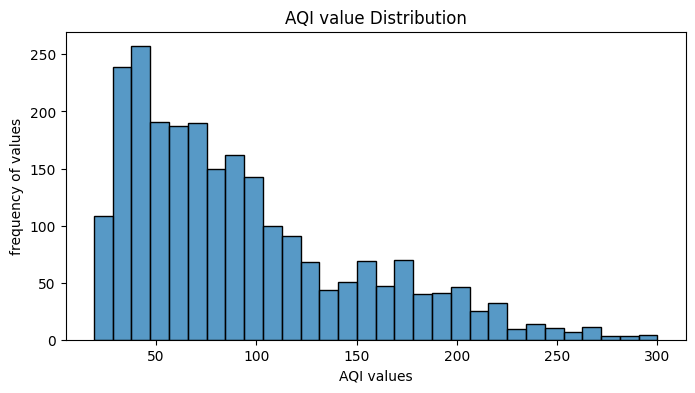

In [98]:
plt.figure(figsize=(8,4))
sns.histplot(df['Index Value'], bins=30)
plt.xlabel("AQI values")
plt.ylabel('frequency of values')
plt.title('AQI value Distribution')
plt.show()

most values aren't extreme and most of them are under 100 and above 40, so its right skewed data

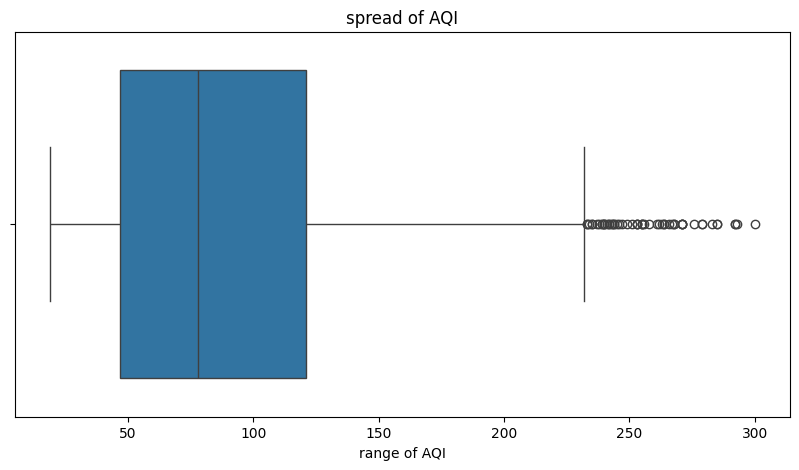

In [103]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Index Value'])
plt.title('spread of AQI')
plt.xlabel('range of AQI')
plt.show()

so as we saw, average aqi is around 70-80, q1 ~ 50 and q3 ~ 120 so most values lies within this bracket, lowest was around 20 andd highest was around 230, so above 230 there are lots of outliers till 300 AQI and we need to handle them.

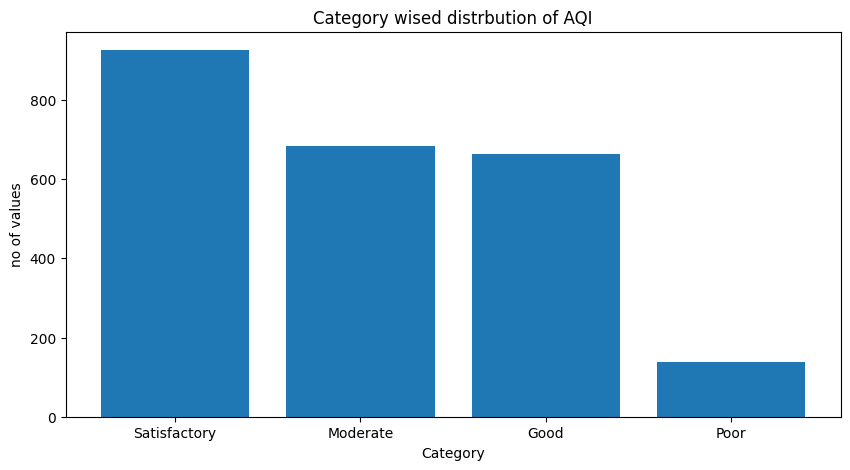

In [109]:
plt.figure(figsize=(10,5))
plt.bar(df['Air Quality'].value_counts().index,
     df['Air Quality'].value_counts().values )
plt.title('Category wised distrbution of AQI')
plt.xlabel('Category')
plt.ylabel("no of values")

plt.show()

most values lie within 3 major categories, but importantly most values are satisfactory(900-1000)

([<matplotlib.patches.Wedge at 0x7a5dcfc50fe0>,
 [Text(-1.0276555713397317, 0.3923315265109465, 'Satisfactory'),
  Text(0.1754735696171201, -1.0859139129626372, 'Moderate'),
  Text(1.035607894958199, 0.370831886304627, 'Good'),
  Text(0.19806407771820073, 1.0820215437400675, 'Poor')],
 [Text(-0.5605394025489445, 0.21399901446051625, '38.4%'),
  Text(0.09571285615479277, -0.592316679797802, '28.3%'),
  Text(0.5648770336135631, 0.20227193798434198, '27.5%'),
  Text(0.10803495148265493, 0.590193569312764, '5.8%')])

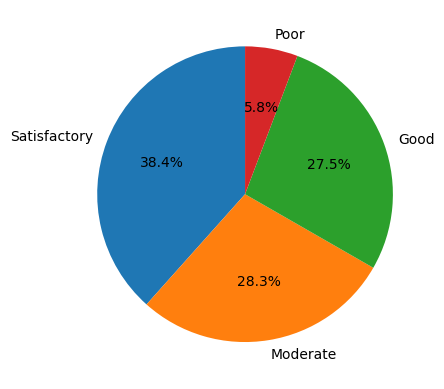

In [122]:
plt.figure(6.7)

plt.pie(
   labels= df["Air Quality"].value_counts().index,
    x= df["Air Quality"].value_counts().values,
    autopct="%1.1f%%",
  startangle=90)

nashik already has acceptable AQI as pie chart shows,only a minor ~8% is poor air

#  Bivariate analysis
so far we understood single variables and their spread, time for relationships of two variables


In [ ]:
we need date function so its better to convert it into datetime

In [123]:
df['date']=pd.to_datetime(df['date'])

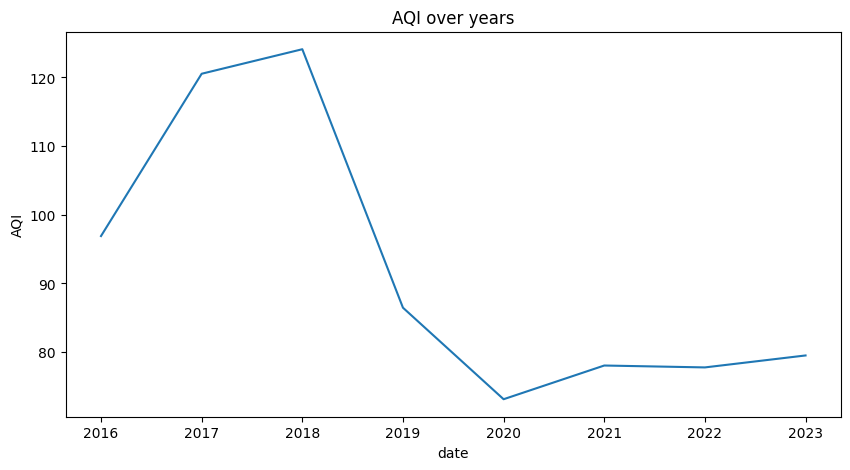

In [133]:
plt.figure(figsize=(10,5))
year_by_year=df.groupby(df['date'].dt.year)['Index Value'].mean()
plt.plot(year_by_year.index,year_by_year.values)
plt.title('AQI over years')
plt.xlabel('date')
plt.ylabel("AQI")
plt.show()

AQI was significantly higher in 2016-2018 bracket averaging ~110-125, it started increasing from 2016  and reached its peak in 2018, then showed a sharp decline over next to years  with 2020  recording lowest ever and since 2020 its increasing by a minor margin. so AQI in nashik has been consistent in recent years

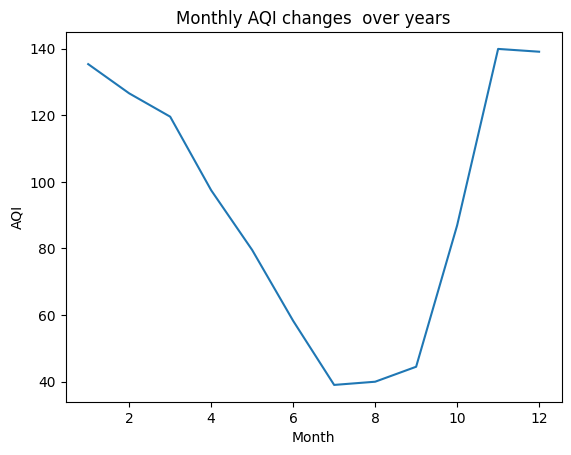

In [134]:
month_by_month=df.groupby(df['date'].dt.month)['Index Value'].mean()
plt.plot(month_by_month.index,month_by_month.values)
plt.title('Monthly AQI changes  over years')
plt.xlabel('Month')
plt.ylabel("AQI")
plt.show()

similarly if we look at monthly data, first 3 months  have higher AQI, with consistent decline until 7 th month of july,recording lowest AQI(~40) in a year,it further increases sharply till 12 th month december at ~ 140 AQI

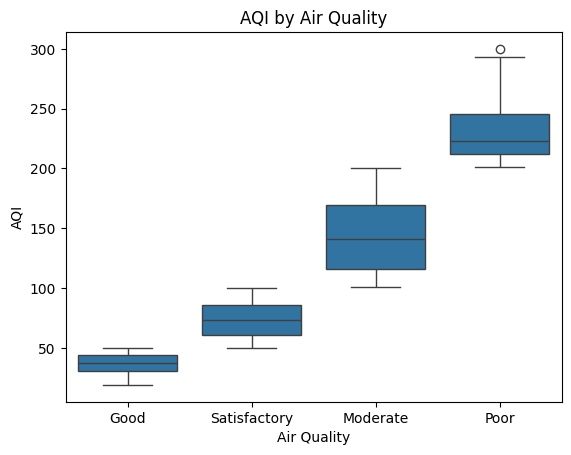

In [145]:
sns.boxplot(x=df['Air Quality'] , y=df['Index Value'],order=["Good", "Satisfactory", "Moderate", "Poor"])
plt.title("AQI by Air Quality")
plt.xlabel("Air Quality")
plt.ylabel("AQI")
plt.show()

as categories suggest each category represents its values very well,so data is consistent


**This concludes our EDA and we can move ahead for feature engineering**